# Chapter 12 — Softmax Regression

**Goals**

- Generalize logistic regression to $K > 2$ classes.
- Implement softmax + multi-class cross-entropy + GD from scratch.
- Use the log-sum-exp trick for numerical stability.
- Verify against `sklearn.linear_model.LogisticRegression(multi_class='multinomial')`.
- Visualize the learned weight templates on the Digits dataset.

Pair with `docs/04_classification.md`, Part D.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.special import logsumexp

SEED = 42
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)

## 2. The softmax function

For logits $\mathbf{z} \in \mathbb{R}^K$:
$$\mathrm{softmax}(\mathbf{z})_c = \frac{e^{z_c}}{\sum_k e^{z_k}}.$$
Use the log-sum-exp trick to avoid overflow when $z_c$ is large.

In [2]:
def softmax(Z):
    # Z shape (N, K). Returns same shape with rows summing to 1.
    Z_shift = Z - Z.max(axis=1, keepdims=True)
    expZ = np.exp(Z_shift)
    return expZ / expZ.sum(axis=1, keepdims=True)

z = np.array([[2.0, 1.0, 0.1],
              [-1.0, -1.0, -1.0],
              [10.0, 1.0, 0.0]])
print('softmax:')
print(softmax(z))
print('row sums:', softmax(z).sum(axis=1))

softmax:
[[0.659  0.2424 0.0986]
 [0.3333 0.3333 0.3333]
 [0.9998 0.0001 0.    ]]
row sums: [1. 1. 1.]


## 3. Softmax regression from scratch

Parameters: weight matrix $\mathbf{W} \in \mathbb{R}^{d \times K}$ plus per-class bias $\mathbf{b} \in \mathbb{R}^{K}$, absorbed by augmenting $\mathbf{X}$ with a 1-column.
Loss = average negative log-probability of the true class.
Gradient = $\frac{1}{N} \mathbf{X}^\top (\hat{\mathbf{P}} - \mathbf{Y}_{\text{onehot}})$.

In [3]:
class SoftmaxRegression:
    def __init__(self, lr=0.5, n_iters=400, l2=0.0):
        self.lr = lr; self.n_iters = n_iters; self.l2 = l2

    def _augment(self, X):
        return np.hstack([X, np.ones((X.shape[0], 1))])

    def fit(self, X, y):
        Xb = self._augment(X)
        self.classes_ = np.unique(y)
        K = len(self.classes_)
        Y = np.eye(K)[y]                         # one-hot, (N, K)
        self.W_ = np.zeros((Xb.shape[1], K))
        self.history_ = []
        for _ in range(self.n_iters):
            logits = Xb @ self.W_
            log_norm = logsumexp(logits, axis=1, keepdims=True)
            log_probs = logits - log_norm
            loss = -np.mean(log_probs[np.arange(len(y)), y]) + self.l2 * np.sum(self.W_ ** 2) / (2 * len(y))
            self.history_.append(float(loss))
            P = np.exp(log_probs)
            grad = (Xb.T @ (P - Y)) / len(y) + self.l2 * self.W_ / len(y)
            self.W_ -= self.lr * grad
        return self

    def predict_proba(self, X):
        Xb = self._augment(X)
        logits = Xb @ self.W_
        return np.exp(logits - logsumexp(logits, axis=1, keepdims=True))

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

## 4. Train on Digits (8×8 handwritten digits)

In [4]:
digits = load_digits()
X, y = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

scratch = SoftmaxRegression(lr=0.5, n_iters=400, l2=0.01).fit(X_train_s, y_train)
sk = LogisticRegression(max_iter=2000, random_state=SEED).fit(X_train_s, y_train)

print(f'scratch test accuracy = {accuracy_score(y_test, scratch.predict(X_test_s)):.4f}')
print(f'sklearn test accuracy = {accuracy_score(y_test, sk.predict(X_test_s)):.4f}')

scratch test accuracy = 0.9639
sklearn test accuracy = 0.9722


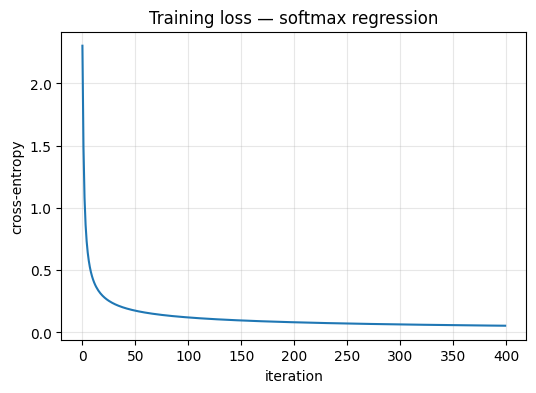

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(scratch.history_)
ax.set_xlabel('iteration'); ax.set_ylabel('cross-entropy')
ax.set_title('Training loss — softmax regression')
ax.grid(True, alpha=0.3)
plt.show()

## 5. Visualize the learned templates

Each column of `W_[:64]` is a learned 8×8 weight image. Bright = positive, dark = negative.

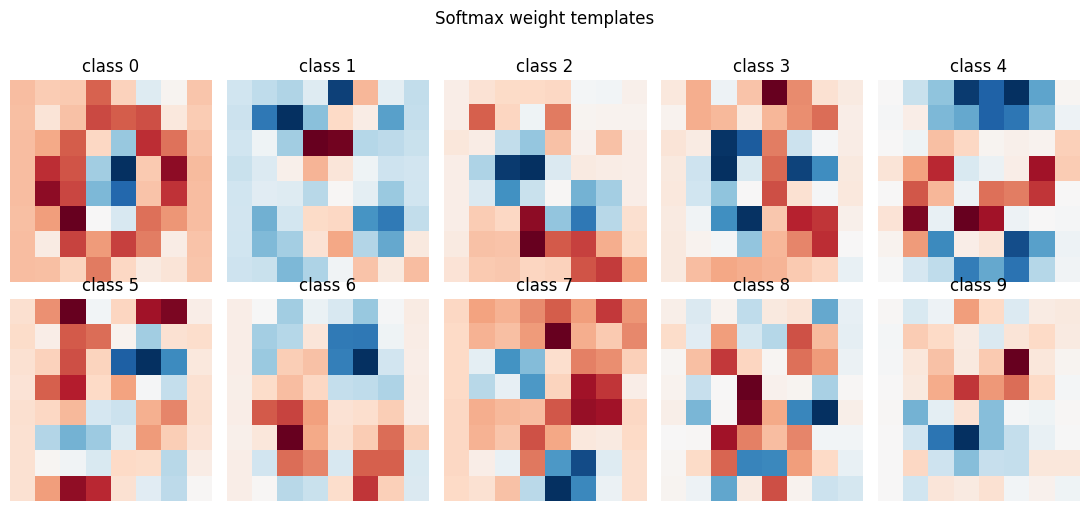

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for c in range(10):
    ax = axes[c // 5, c % 5]
    template = scratch.W_[:64, c].reshape(8, 8)
    ax.imshow(template, cmap='RdBu_r')
    ax.set_title(f'class {c}'); ax.axis('off')
plt.suptitle('Softmax weight templates', y=1.02)
plt.tight_layout()
plt.show()

Each template loosely resembles the digit it detects: positive (red) regions where that digit usually has ink, negative (blue) where it doesn't. This is the strongest case for *interpretable linear models*.

## 6. Confusion matrix

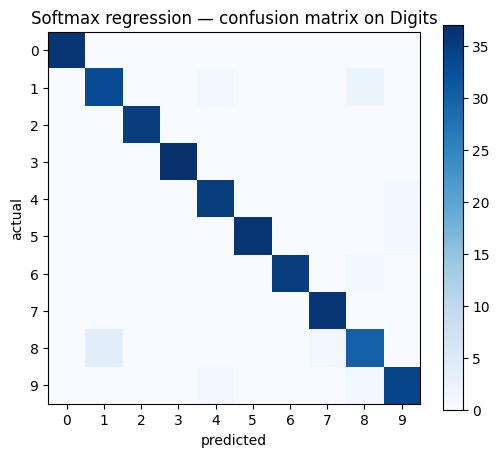

misclassified = 13 / 360


In [7]:
y_pred = scratch.predict(X_test_s)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
ax.set_title('Softmax regression — confusion matrix on Digits')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
plt.colorbar(im, ax=ax)
plt.show()

off_diag = cm.sum() - cm.trace()
print(f'misclassified = {off_diag} / {cm.sum()}')

## 7. Summary

- Softmax extends logistic regression from 2 → $K$ classes; the loss and gradient look the same.
- `logsumexp` is non-optional in code — without it large logits will overflow.
- L2 regularization (small `l2`) helps avoid extreme weights when features are correlated.
- The learned templates show what the model latched onto — a free interpretability bonus.

**Next:** the same kind of "learn a linear decision rule" idea but applied unsupervised — `notebooks/chapter_07_kmeans.ipynb`.

## Quick Check

1. Why subtract the max of the logits before exponentiating in softmax?
2. What is the relationship between binary cross-entropy and categorical cross-entropy?
3. Why is one-hot encoding used for multi-class labels but not for ordinal regression?
4. State the decision rule for softmax classification.
5. What is the gradient of softmax cross-entropy w.r.t. logits? (Hint: very clean.)


## Further Reading

- Vũ Hữu Tiệp, *Machine Learning cơ bản* — Chương 15 (Softmax Regression).
- Andrew Ng, *CS229 Lecture Notes* — Softmax regression.
- scikit-learn user guide: *Multiclass and multilabel algorithms*.
